# Task 1 - Data Loading & Exploration

In [2]:
#import the required libraries 

import pandas as pd
import numpy as np        

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Machine Learning 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [4]:
#Evaluation metrics

from sklearn.metrics import(
classification_report,
confusion_matrix,
roc_auc_score,
roc_curve
)


In [5]:
#import warnings

import warnings 
warnings.filterwarnings('ignore')

In [6]:
#Load the Dataset 
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [7]:
#display first 10 rows 
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [8]:
#Number of Rows and Columns
print("Shape of Dataset: ")
print(df.shape)

Shape of Dataset: 
(1470, 35)


In [9]:
#list all columns 
print(df.columns.tolist())

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [11]:
df.describe() #statistics summary

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [12]:
#Target Variable
print(df['Attrition'].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [13]:
#Attrition Rate as % 
attrition_rate = (df['Attrition']=='Yes').mean()*100
print(f"Attrition Rate : {attrition_rate:.2f}%")

Attrition Rate : 16.12%


In [14]:
#Numeric vs Categorical 
num_cols=df.select_dtypes(include=np.number)
cat_cols=df.select_dtypes(exclude=np.number)

print("Numeric Columns: ")
print(len(num_cols.columns))

print("Categorical Columns:")
print(len(cat_cols.columns))

Numeric Columns: 
26
Categorical Columns:
9


observation about the attrition rate :

The dataset is imbalanced because only 237 out of 1,470 employees (approximately 16.12%) left the company, while 1,233 employees (approximately 83.88%) stayed. Since the majority class ("No") significantly outweighs the minority class ("Yes").

This imbalance should be considered during model training to ensure the model learns to identify employees who are likely to leave.

Therefore, techniques such as using class_weight='balanced' are appropriate.



# Task 2 - Data Cleaning & Preprocessing 

In [15]:
#check for missing /null values 

print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [16]:
#total missing values 
print("Total missing values:")
print(df.isnull().sum().sum())

Total missing values:
0


In [17]:
#drop columns that add no value to prediction
df.drop(['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount'], axis=1, inplace=True)

In [18]:
#convert target columns attrition
df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})



In [19]:
#one hot encoding 
df = pd.get_dummies(df, drop_first=True)
print(df.shape)

(1470, 45)


In [20]:
# Separate Features and Target 
#defining x and y 

x = df.drop('Attrition', axis=1)
y = df['Attrition']

In [21]:
#Standard Scaling 
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()

#train test split 

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.20, random_state=42, stratify=y)

x_train =  scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [22]:
print("Shape of x_train:", x_train.shape)
print("Shape of x_test:", x_test.shape)

Shape of x_train: (1176, 44)
Shape of x_test: (294, 44)


# Task 3 — Exploratory Data Analysis — EDA 

In [23]:
# for eda we need origional dataset
eda_df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [24]:
# Attrition rate by Department 
dept_attrition = eda_df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack()*100
dept_attrition

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


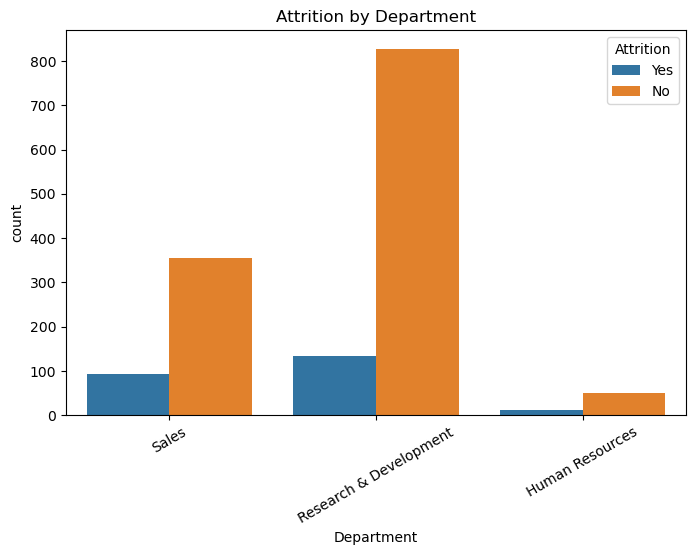

In [25]:
#plot of attrition rate by department 
plt.figure(figsize=(8,5))

sns.countplot(x='Department', hue='Attrition', data =eda_df)
plt.title("Attrition by Department")
plt.xticks(rotation=30)
plt.show()

The Sales department has the highest employee attrition rate (20.63%), followed by Human Resources (19.05%). Research & Development has the lowest attrition rate (13.84%).

In [26]:
# Attrition rate by Job Role
job_attrition = eda_df.groupby('JobRole')['Attrition'].value_counts(normalize=True).unstack()*100
job_attrition

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


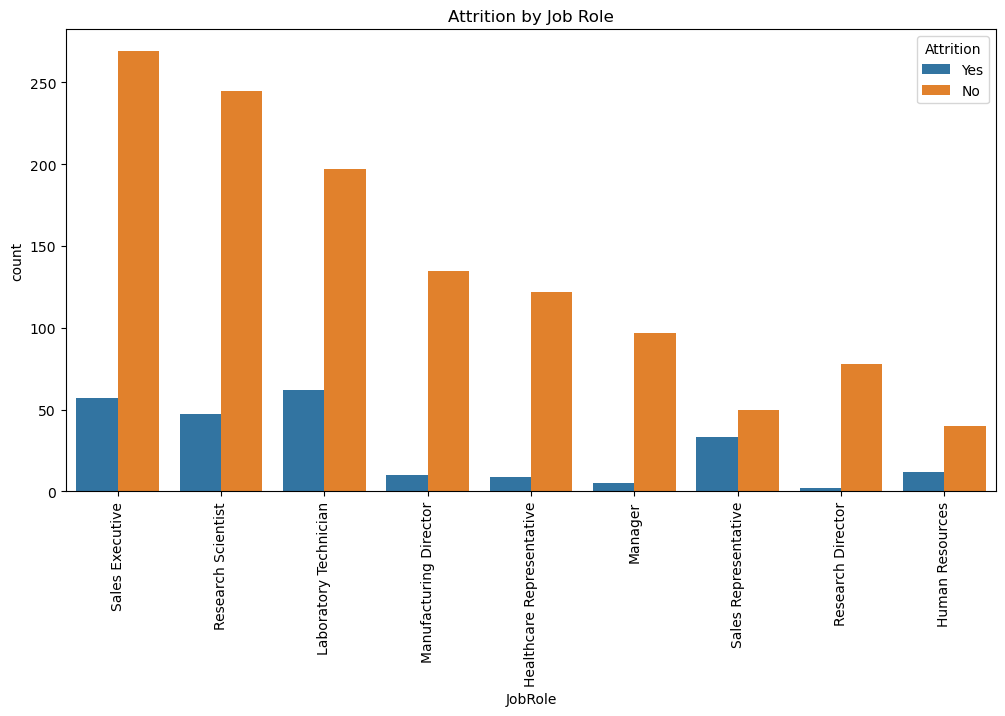

In [27]:
#Attrition rate by Job Role plot
plt.figure(figsize=(12,6))

sns.countplot(x='JobRole', hue='Attrition', data = eda_df)

plt.xticks(rotation = 90)
plt.title("Attrition by Job Role")
plt.show()

Sales Representatives have the highest attrition rate (39.76%), followed by Laboratory Technicians (23.94%) and Human Resources employees (23.08%). These roles experience significantly higher employee turnover than others and should be prioritized for retention initiatives.

In [28]:
# Attrition rate by Income
income_attrition = eda_df.groupby('MonthlyIncome')['Attrition'].value_counts(normalize=True).unstack()
income_attrition

Attrition,No,Yes
MonthlyIncome,,
1009,NaN,1.0
1051,1.0,NaN
1052,1.0,NaN
1081,NaN,1.0
1091,NaN,1.0
...,...,...
19859,NaN,1.0
19926,1.0,NaN
19943,1.0,NaN


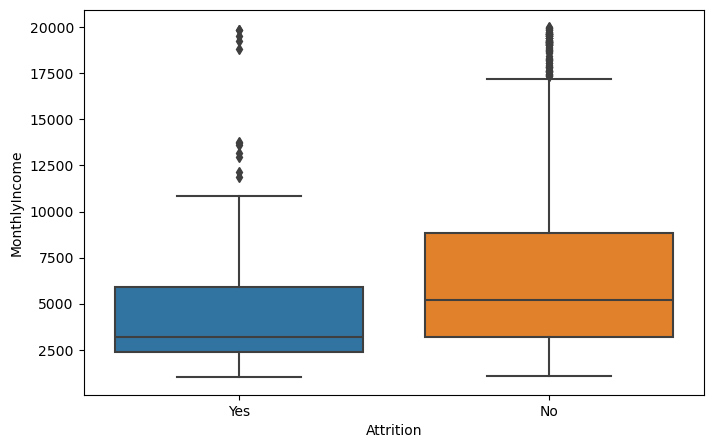

In [29]:
#Attrition rate by Income plot
plt.figure(figsize=(8,5))

sns.boxplot(x='Attrition', y='MonthlyIncome', data = eda_df)


plt.show()

Employees who left the company earned considerably lower salaries on average than those who stayed.

In [30]:
# Attrition rate by Work Life Balance 
worklife_attrition = eda_df.groupby('WorkLifeBalance')['Attrition'].value_counts(normalize=True).unstack()*100
worklife_attrition

Attrition,No,Yes
WorkLifeBalance,,
1,68.750000,31.250000
2,83.139535,16.860465
3,85.778275,14.221725
4,82.352941,17.647059


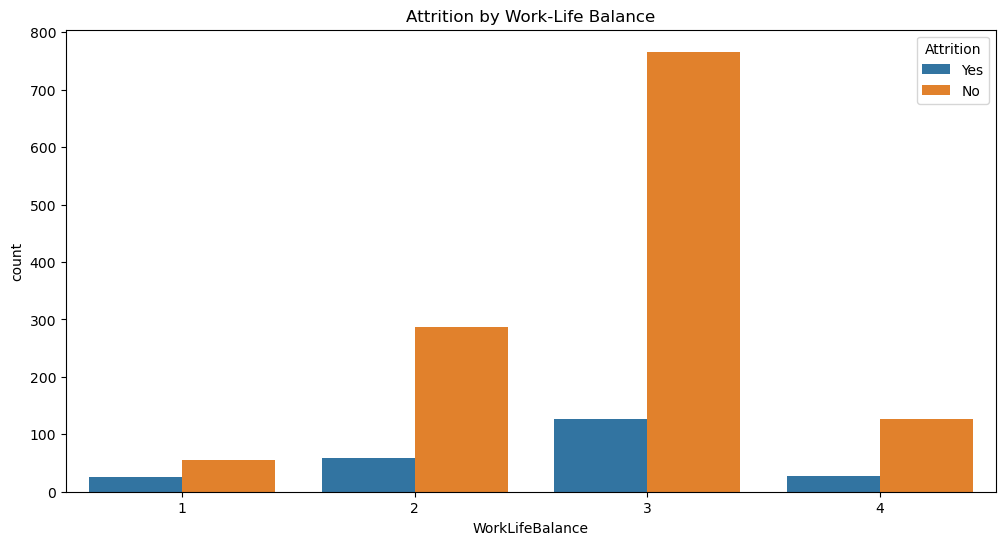

In [31]:
#Attrition rate by Work Life Balance 
plt.figure(figsize=(12,6))

sns.countplot(x='WorkLifeBalance', hue='Attrition', data = eda_df)

plt.xticks(rotation = 0)
plt.title("Attrition by Work-Life Balance")
plt.show()

Employees with the lowest work-life balance rating have the highest attrition rate (31.25%), indicating that poor work-life balance is strongly associated with employee turnover.

Yes, there is a visible pattern, but it's not perfectly linear.

In [32]:
# Attrition rate by Years at Company
years_attrition = eda_df.groupby('YearsAtCompany')['Attrition'].value_counts(normalize=True).unstack()*100
years_attrition

Attrition,No,Yes
YearsAtCompany,,
0,63.636364,36.363636
1,65.497076,34.502924
2,78.740157,21.259843
3,84.375000,15.625000
4,82.727273,17.272727
5,89.285714,10.714286
6,88.157895,11.842105
7,87.777778,12.222222
8,88.750000,11.250000


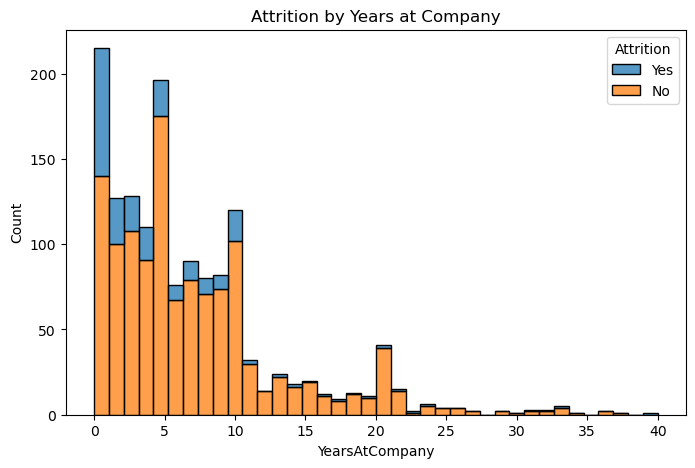

In [33]:
#Attrition rate by Years at Company plot 
plt.figure(figsize=(8,5))

sns.histplot(data = eda_df, x='YearsAtCompany', hue='Attrition', multiple='stack')

plt.xticks(rotation = 0)
plt.title("Attrition by Years at Company")
plt.show()

Most employees who left the company had less than five years of service, with the highest number of exits occurring around 1 year at the company.

# Business Insights from EDA 
* Insight 1 : The Sales department has the highest employee turnover. This means HR should pay extra attention to retaining employees in this department.
  
* Insight 2 : Sales Representatives leave the company more often than any other job role. They should be the first group considered for retention programs and regular employee feedback.
  
* Insight 3 : Employees with lower monthly salaries are more likely to leave the company. This suggests that reviewing compensation and rewards may help reduce employee turnover.
  
* Insight 4 : Employees who reported poor work-life balance were much more likely to resign. Providing flexible work options and reducing workload could improve employee satisfaction and retention.
  
* Insight 5 : Most employees leave within their first five years, especially during the first year. A stronger onboarding process, mentoring, and regular check-ins with new employees could help keep them in the company longer.

# Task 4 — Model Building & Comparison


In [34]:
#Separating the Features and Target variable 
x = df.drop('Attrition', axis=1)
y = df['Attrition']

print("Feature Shape: ",x.shape)
print("Target Shape: ",y.shape)

Feature Shape:  (1470, 44)
Target Shape:  (1470,)


In [35]:
#Split the data by 80/20

#TRAIN TEST SPLIT 

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20,random_state=42,
    stratify=y)

print("Training Data :", x_train.shape)
print("Testing Data :", x_test.shape)

Training Data : (1176, 44)
Testing Data : (294, 44)


In [36]:
#class imbalance handle 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit scaler on training data and transform
x_train = scaler.fit_transform(x_train)

# Transform testing data
x_test = scaler.transform(x_test)

print("Class Imbalance Handle Completed Successfully!")

Class Imbalance Handle Completed Successfully!


In [37]:
#LOGISTIC REGRESSION 

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(class_weight='balanced', random_state = 42)

#train the model
lr_model.fit(x_train, y_train)
print("Logistic Regression Model Done")

Logistic Regression Model Done


In [38]:
#prediction
lr_pred = lr_model.predict(x_test)
lr_prob = lr_model.predict_proba(x_test)[:,1]

In [39]:
# RANDOM FOREST 
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state = 42)
rf_model.fit(x_train,y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [40]:
#prediction
rf_pred = rf_model.predict(x_test)
rf_prob = rf_model.predict_proba(x_test)[:,1]

In [41]:
#GRADIENT BOOSTING
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state = 42)

#train
gb_model.fit(x_train, y_train)

GradientBoostingClassifier(random_state=42)

In [42]:
#prediction

gb_pred = gb_model.predict(x_test)
gb_prob = gb_model.predict_proba(x_test)[:, 1]

In [43]:
# MODEL COMPARISON TABLE

comparison_table = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    
    "Algorithm Type": [
        "Linear Classification",
        "Ensemble (Bagging)",
        "Ensemble (Boosting)"
    ],
    
    "Class Imbalance Handling": [
        "class_weight='balanced'",
        "class_weight='balanced'",
        "Not Supported"
    ],
    
    "Model Status": [
        "Trained",
        "Trained",
        "Trained"
    ]
})

comparison_table

,Model,Algorithm Type,Class Imbalance Handling,Model Status
0,Logistic Regression,Linear Classification,class_weight='balanced',Trained
1,Random Forest,Ensemble (Bagging),class_weight='balanced',Trained
2,Gradient Boosting,Ensemble (Boosting),Not Supported,Trained


# Task 5 - Model Evaluation

In [44]:
#evaluation
#import the metrics

from sklearn.metrics import(accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
                         classification_report, ConfusionMatrixDisplay)

In [45]:
# Model Evaluation Function

def evaluate_model(model_name, y_true, y_pred, y_prob):

    print("="*60)
    print(f"{model_name} Evaluation")
    print("="*60)

    print("Classification Report\n")
    print(classification_report(y_true, y_pred))

    print("Precision :", round(precision_score(y_true, y_pred),4))
    print("Recall    :", round(recall_score(y_true, y_pred),4))
    print("F1-Score  :", round(f1_score(y_true, y_pred),4))
    print("ROC-AUC   :", round(roc_auc_score(y_true, y_prob),4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues')

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Logistic Regression Evaluation
Classification Report

              precision    recall  f1-score   support

           0       0.91      0.77      0.84       247
           1       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294

Precision : 0.3412
Recall    : 0.617
F1-Score  : 0.4394
ROC-AUC   : 0.7988


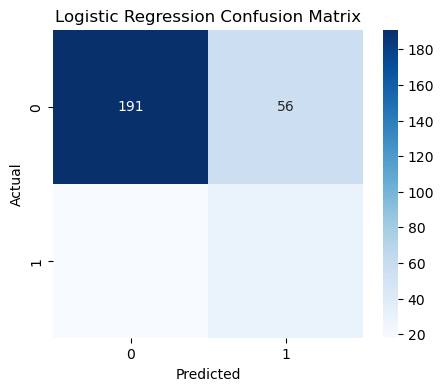

In [46]:
#evaluate logistic regression

evaluate_model("Logistic Regression", y_test,lr_pred, lr_prob )

Random Forest Evaluation
Classification Report

              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294

Precision : 0.4444
Recall    : 0.0851
F1-Score  : 0.1429
ROC-AUC   : 0.7547


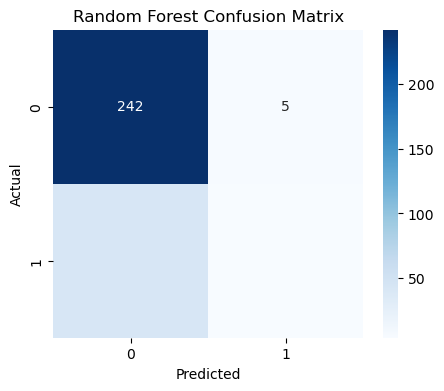

In [47]:
#random forest evaluate

evaluate_model("Random Forest", y_test, rf_pred, rf_prob)

Gradient Boosting Evaluation
Classification Report

              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294

Precision : 0.5882
Recall    : 0.2128
F1-Score  : 0.3125
ROC-AUC   : 0.7944


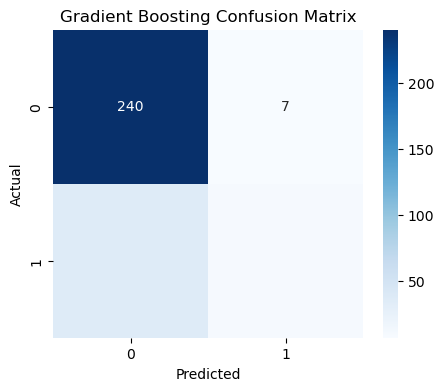

In [48]:
#Gradien Boosting Evaluate 
evaluate_model("Gradient Boosting", y_test, gb_pred, gb_prob)

In [49]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Precision":[
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],
     "Recall":[
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],

    "F1 Score":[
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ],
    "ROC-AUC":[
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, gb_prob)
    ]

})

comparison = comparison.round(4)

comparison
    
    

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.3412,0.6170,0.4394,0.7988
1,Random Forest,0.4444,0.0851,0.1429,0.7547
2,Gradient Boosting,0.5882,0.2128,0.3125,0.7944


The model Gradient Boosting performance is the best. It achieved the highest Precision(0.5882), the highest F1-Score(0.3125), and the highest ROC-AUC score (0.7944). 

Although Logistic Regression had a higher Recall, Gradient Boosting provided the best overall balance in identifying employees who are likely to leave.

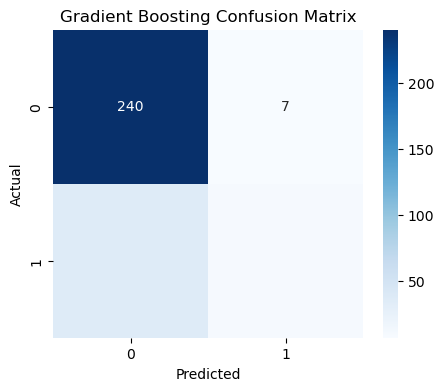

In [50]:
#Confusion Matrix of Best Model

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, gb_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [51]:
#Feature Importance of best model 
feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": gb_model.feature_importances_})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False)

feature_importance.head(10)

,Feature,Importance
9,MonthlyIncome,0.109081
0,Age,0.093560
43,OverTime_Yes,0.088694
16,TotalWorkingYears,0.084067
11,NumCompaniesWorked,0.050086
15,StockOptionLevel,0.047109
1,DailyRate,0.045122
22,YearsWithCurrManager,0.043466
4,EnvironmentSatisfaction,0.038851
2,DistanceFromHome,0.038060


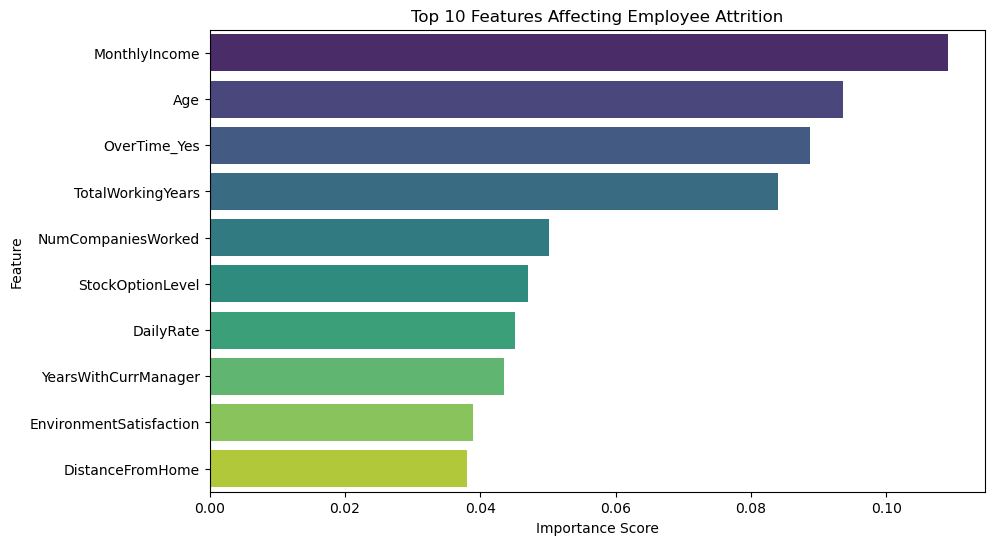

In [52]:
#Top 10 important features - PLOT
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 10 Features Affecting Employee Attrition")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

In [53]:
#top 10 important features - DISPLAY

top10 = feature_importance.head(10)
top10

,Feature,Importance
9,MonthlyIncome,0.109081
0,Age,0.093560
43,OverTime_Yes,0.088694
16,TotalWorkingYears,0.084067
11,NumCompaniesWorked,0.050086
15,StockOptionLevel,0.047109
1,DailyRate,0.045122
22,YearsWithCurrManager,0.043466
4,EnvironmentSatisfaction,0.038851
2,DistanceFromHome,0.038060


* Observation: The Gradient Boosting model identified the above features as the most important factors influencing employee attrition. Features with higher importance scores have a greater impact on predicting whether an employee is likely to leave the company.

# Task 6 — Visualization 

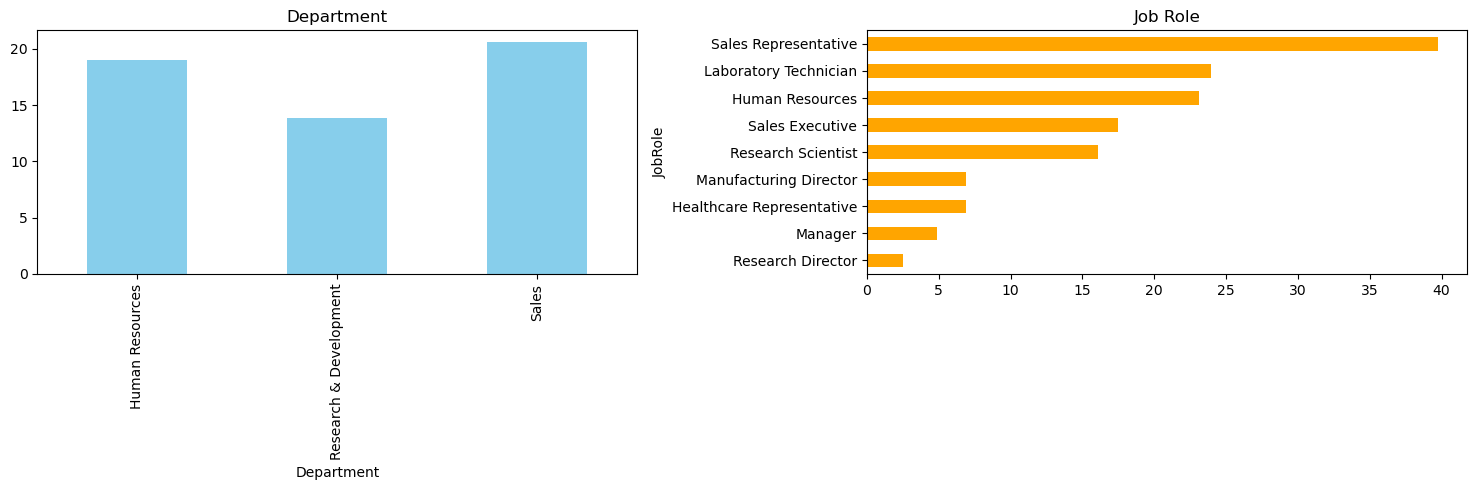

In [54]:
#Chart 1: Bar chart showing attrition rate by Department and Job Role

plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
dept = eda_df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack()*100
dept['Yes'].plot(kind='bar', color='skyblue')
plt.title("Department")

plt.subplot(1,2,2)
job = eda_df.groupby('JobRole')['Attrition'].value_counts(normalize=True).unstack()*100
job['Yes'].sort_values().plot(kind='barh', color='orange')
plt.title("Job Role")

plt.tight_layout()
plt.savefig("chart1_department_jobrole_attrition.png")
plt.show()

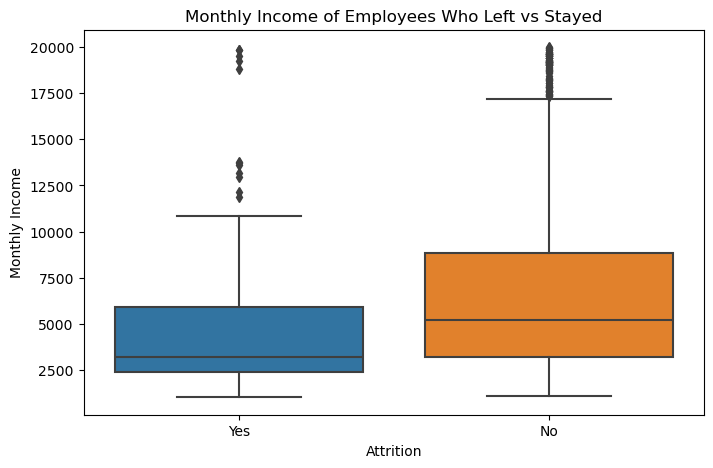

In [55]:
#Chart 2: Box plot comparing Monthly Income of employees who left vs stayed

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=eda_df
)

plt.title("Monthly Income of Employees Who Left vs Stayed")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

# Save chart
plt.savefig("chart2_monthly_income.png", dpi=300)

plt.show()

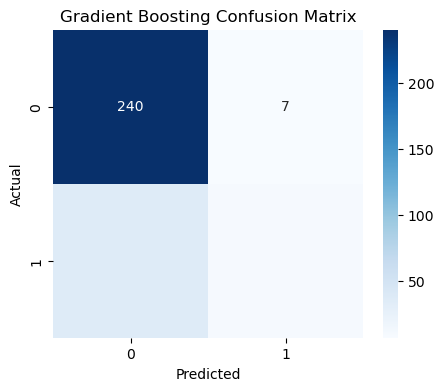

In [56]:
#Chart 3: Confusion Matrix heatmap for best model

cm = confusion_matrix(y_test, gb_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues')

plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("chart3_confusion_matrix.png", dpi=300, bbox_inches='tight')

plt.show()

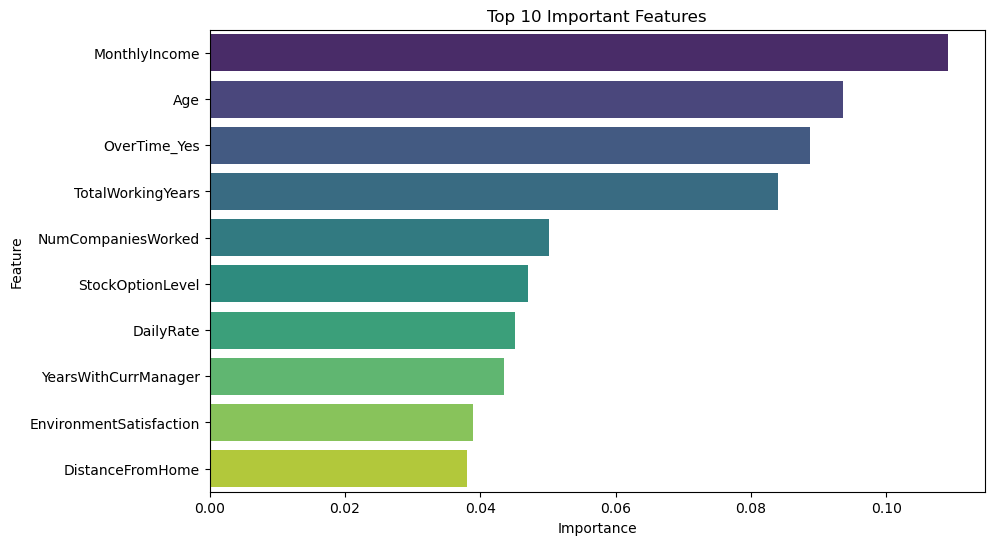

In [57]:
# Chart 4: Horizontal bar chart of Top 10 Feature Importances from your best model

feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": gb_model.feature_importances_})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.savefig("chart4_feature_importance.png", dpi=300, bbox_inches='tight')

plt.show()

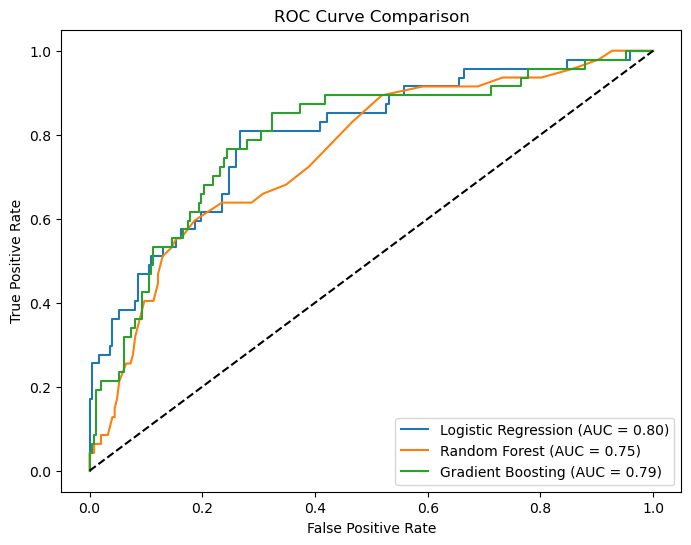

In [58]:
# Chart 5 : ROC Curve comparing all 3 models on one graph
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curve for each model
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)

plt.figure(figsize=(8,6))

# Logistic Regression
plt.plot(lr_fpr, lr_tpr,label=f"Logistic Regression (AUC = {roc_auc_score(y_test, lr_prob):.2f})")

# Random Forest
plt.plot(rf_fpr, rf_tpr,label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.2f})")

# Gradient Boosting
plt.plot(gb_fpr, gb_tpr,label=f"Gradient Boosting (AUC = {roc_auc_score(y_test, gb_prob):.2f})")

# Random Guess Line
plt.plot([0,1], [0,1], 'k--')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.savefig("chart5_roc_curve.png", dpi=300)
plt.show()

# Task 7 — HR Insights & Business Recommendations

From the analysis we can say that, the three strongest factors influence that employee can leave are:- 
* working overtime
* monthly income
* years at the company.

Employees in the Sales department, particularly Sales Representatives, have the highest attrition rate and should be the primary focus of retention efforts. 
Although employees with lower salaries are more likely to leave, salary alone does not explain attrition. Other factors such as work-life balance, overtime, job satisfaction, and employee experience also play an important role.

To reduce attrition, HR should conduct regular retention discussions with employees in high-risk roles and improve work-life balance through flexible work policies and workload management. Additionally, strengthening onboarding, mentoring, and career development programs for employees in their first few years may help reduce early resignations.

One limitation of this model is that it predicts attrition based only on the available historical HR data and cannot account for personal reasons, future business changes, or external factors that may influence an employee's decision to leave.